# <font color="brown">🎓&nbsp;&nbsp; Introduction</font>

In this exercice, you will discover an interesting way to use genetic algorithm: image recreation.

This is inspired by the Genetic Programming implementation of this by Roger Johansson (https://rogerjohansson.blog/2008/12/07/genetic-programming-evolution-of-mona-lisa/) and the countless Genetic Algorithm implementations that followed.

## <font color="brown">🏕&nbsp;&nbsp; Environment</font>
This notebook has been tested on Google Colab but you can run it elsewhere. Just make sure to put the image you want to recreate either on Google Drive or on your disk depending on the platform of your choice.

## <font color="brown">🏗&nbsp;&nbsp; Load image and libraries</font>

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#%pip install pygad

In [ ]:
import numpy as np
import cv2

original_image = cv2.imread('./spyro.png') # Load image (change this path if needed)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB) # Convert image from BGR format to RGB
original_image = cv2.resize(original_image, (original_image.shape[1] // 4, original_image.shape[0] // 4)) # Resize image
original_image = np.float32(original_image) / 255 # Rescale image to [0, 1]

In [ ]:
import matplotlib.pyplot as plt
from skimage import filters

plt.figure(dpi=40) # Change the resolution at which we plot the image
plt.imshow(original_image)
plt.axis('off'); # Do not plot axes for this figure

## <font color="brown">✍️&nbsp;&nbsp; Configure some parameters</font>

Note that the parameters values here have been chosen based on some experiments on our part.

In [ ]:
import pygad
import numpy as np

# RGB mean and std taken from the original image
RGB_MEAN, RGB_STD = np.mean(original_image, axis=(0, 1)), np.std(original_image, axis=(0, 1))

# Image's width and height
IMG_HEIGHT, IMG_WIDTH = original_image.shape[:2]

# Number of corners per shapes
N_SHAPE_CORNERS = 4

# RGB + (X,Y) * CORNERS
N_PROPERTIES = 3 + 2 * N_SHAPE_CORNERS

# Number of shapes for each paintings "layers"
N_SHAPES_LIST = [120, 60, 20]

# Number of populations individuals for each paintings "layers"
N_INDIVIDUAL_LIST = [250, 500, 500]

# The transparency at which we paint the shapes on top of each other for each painting layers
TRANSPARENCY_LIST = [0.8, 0.6, 0.4]

# The number of painting layers
N_STEP = len(N_SHAPES_LIST)

## <font color="brown">🔧&nbsp;&nbsp; Define utils functions</font>

### <font color="brown">Chromosome Encoding</font>
Our chromosome is encoded as follow:

\[Red, Green, Blue, X1, Y1, X2, Y2, X3, Y3, X4, Y4\], where X _i_ and Y _i_ are the coordinates of the corner _i_ of the shape.

### <font color="brown">Initial Population</font>
We generate a value between 0 and 1 regardless of the gene, be it a color or a coordinate. It makes it easier for the evolution to have all the genes with the same scale. We will recover the right scale when drawing the image corresponding to a chromosome.

We've computed the mean and standard deviation of the red, blue and green values of the image we aim to recreate. We will generate a first population by sampling color distributed on a normal with those mean and standard deviation to help a bit finding colors close to the images ones.

In [ ]:
def generate_random_chromosomes(n_shapes):
  chromosomes = np.empty((n_shapes * N_PROPERTIES))

  for shape_idx in range(0, n_shapes * N_PROPERTIES, N_PROPERTIES):
      # Generate chromosome color values
      chromosomes[shape_idx : (shape_idx + 3)] = np.random.normal(RGB_MEAN, RGB_STD, size=3)

      # Generate chromosome coordinates values
      chromosomes[(shape_idx + 3) : (shape_idx + 3 + 2 * N_SHAPE_CORNERS)] = np.random.uniform(0, 1, size=(2 * N_SHAPE_CORNERS))

  return np.clip(chromosomes, 0, 1) # Ensure all values are constrained between 0 and 1

### <font color="brown">Define callbacks</font>

This callback will be called at each generation. We make a closure function to define a callback that takes a canvas (the background) and a transparency parameter (the transparency at which to draw polygons)


In [ ]:
# Define a closure function on_gen that takes canvas and transparency as arguments
def on_gen(canvas, transparency):

    # Define a nested function on_generation that takes the genetic algorithm instance as argument
    def on_generation(ga_instance):

        # Display the solution fitness and painting each 10 generations
        if (ga_instance.generations_completed - 1) % 10 == 0:
            solution, solution_fitness, solution_idx = ga_instance.best_solution()

            print("Generation: ", ga_instance.generations_completed, ". Fitness: ", solution_fitness)

            # Paint the best solution over the canvas
            # Note that canvas and transparency are passed using the on_gen closure
            solution_image = draw_individual(solution, canvas=canvas, transparency=transparency)

            # Plot it
            plt.figure(dpi=40)
            plt.imshow(solution_image, vmin=0, vmax=255)
            plt.axis('off')
            plt.show()

            # Add this painting to a solution images list (defined outside of this function!)
            # used to make an animation of the training later on
            solution_images.append(solution_image)

    # Return the nested function on_generation
    return on_generation

### <font color="brown">Define how to convert a chromosome to an image</font>

Note that OpenCV expects specific types of values in its functions arguments so be careful to choose correct types if you change this code. Here the colors are given as float between 0 and 1 and we rescale x values from \[0, 1\] to \[0, IMG_WIDTH] and y values to \[0, IMG_HEIGHT]

In [ ]:
def draw_individual(chromosome, canvas, transparency):
    canvas = canvas.copy()
    shapes = np.array(chromosome).reshape((len(chromosome) // N_PROPERTIES, N_PROPERTIES))

    for shape in shapes:
        shape_img = canvas.copy()
        polygon = np.array(shape[3:]).reshape((N_SHAPE_CORNERS, 2))
        polygon[:, 0] *= IMG_WIDTH
        polygon[:, 1] *= IMG_HEIGHT
        polygon = np.int32(polygon)
        color = tuple(shape[:3])

        cv2.fillConvexPoly(shape_img, polygon, color)
        canvas = cv2.addWeighted(shape_img, transparency, canvas, 1 - transparency, 0)

    return canvas

### <font color="brown">Define fitness function</font>

Again a closure function taking canvas and transparency.

The fitness function is the sum of the squared difference between the image we aim to recreate and the one produced. We take the negative value of this error because we don't want to maximize it but to minimize the error!

In [ ]:
def fitness_function(canvas, transparency):
  def fitness_func(ga_instance, solution, solution_idx):
      solution_image = draw_individual(solution, canvas, transparency)
      error = np.sum((original_image - solution_image) ** 2)

      return -error

  return fitness_func

## <font color="brown">🧬&nbsp;&nbsp; Genetic Algorithm Training

Here we do a loop that will train multiple Genetic Algorithms. First we train with a black background and when we find a good image we will use it as background to draw over it and retrain another time. So we will draw by layers.

Doing so help the model to draw details because at each iteration of this, we will draw shapes in order (shapes will be drawn on top of the others) and usually find the general shapes that maximize big surfaces but it will be hard to draw over them. So by starting again with the found image as background we can do some minor adjustments that would have been hard to do otherwise.

In [ ]:
# %matplotlib inline

solution_images = []

# Loop over painting layers
for step in range(N_STEP):
    n_shapes = N_SHAPES_LIST[step]
    n_individual = N_INDIVIDUAL_LIST[step]
    transparency = TRANSPARENCY_LIST[step]

    # Generate an initial population
    initial_population = [generate_random_chromosomes(n_shapes) for i in np.arange(n_individual)]

    # Use a black canvas if this is the first painting layer
    # otherwise use the previous best image as canvas
    if step == 0:
        canvas = np.full_like(original_image, fill_value=0)
    else:
        canvas = best_solution_image.copy()

    print("Step: ", step)

    # Define min and max values for each genes
    gene_space = [
        {'low': 0, 'high': 1}
    ] * N_PROPERTIES * n_shapes

    # Create a new genetic algorithm instance
    ga_instance = pygad.GA(
        num_generations=1000,
        num_parents_mating=round(0.2 * len(initial_population)),
        fitness_func=fitness_function(canvas, transparency),
        initial_population=initial_population,
        gene_type=float,
        gene_space=gene_space,
        on_generation=on_gen(canvas, transparency),
        random_mutation_min_val=-0.15,
        random_mutation_max_val=0.15,
        mutation_type="adaptive",
        mutation_probability=[0.03, 0.01],
        crossover_type="two_points",
        crossover_probability=0.8,
        parent_selection_type="rank",
        stop_criteria="saturate_50",
    )

    # Run genetic algorithm
    ga_instance.run()

    # Save checkpoint
    ga_instance.save(f"GA_checkpoint_{step + 1}")

    # Plot fitness
    ga_instance.plot_fitness()

    # Print best solution results
    solution, solution_fitness, solution_idx = ga_instance.best_solution()
    print("Parameters of the best solution : {solution}".format(solution=solution))
    print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))
    print("Index of the best solution : {solution_idx}".format(solution_idx=solution_idx))

    best_solution_image = draw_individual(solution, canvas=canvas, transparency=transparency)
    solution_images.append(best_solution_image)

    # Plot best solution painting
    plt.figure(dpi=40)
    plt.imshow(best_solution_image, vmin=0, vmax=255)
    plt.axis('off')
    plt.show()


## <font color="brown">🕵️&nbsp;&nbsp; Display Evolution's Animation</font>

In [ ]:
# %matplotlib notebook

# Define the function to animate the plot
def animate(i):
    # Clear the axis
    ax.clear()

    # Plot the data
    ax.imshow(solution_images[i], vmin=0, vmax=255)
    plt.axis('Off')
    plt.show()

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

# Create a figure and axis object
fig, ax = plt.subplots()
anim = animation.FuncAnimation(fig, animate, frames=len(solution_images), interval=100)
HTML(anim.to_html5_video())

## <font color="brown">🎯&nbsp;&nbsp; Your task</font>

Your task is to change this implementation in the following way:

- Instead of using polygons with 4 corners the shape must be ellipses.
- Restrict the colors to a palette of colors (For instance of 32 colors) taken from the original image.
- We don't want transparency anymore.
- Change the image to an image of your choice (please make sure the image size is not too big).

Tips:

- Make sure the lowest value for the lengths is not 0. Otherwise the genetic algorithm could learn to generate "empty" shapes instead of optimizing them. You may also want to generate small shapes by default and let the GA learn to increase their size.
- The easiest way is to generate values between 0 and 1 and then to convert them to the correct ranges for each values (e.g. the image width and height for the position)

_If the training time is a problem, try with fewer shapes, layers and generations. Furthemore, changing some of the GA parameters will help the model converge faster but can sometimes make it more difficult to have good results._

## <font color="brown">🌠&nbsp;&nbsp;Example of result</font>

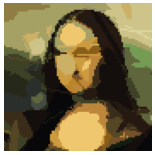

## <font color="brown">📖&nbsp;&nbsp; Report</font>

Please submit in your report:

1. The way you extracted the color palette
2. Your parameters N_SHAPES_LIST, N_INDIVIDUAL_LIST
3. Your parameters to train the genetic algorithm
4. How you define the chromosomes (what are the genes you defined and what they represent)
5. Initial image you choosed and the resulting image you obtained
6. Fitness plots

**Submit your notebook as well**

## Load images 

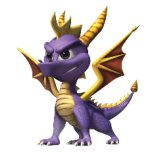

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import filters

original_image = cv2.imread('./spyro_medium.jpg') # Load image (change this path if needed)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB) # Convert image from BGR format to RGB
original_image = cv2.resize(original_image, (original_image.shape[1] // 4, original_image.shape[0] // 4)) # Resize image
original_image = np.float32(original_image) / 255 # Rescale image to [0, 1]

plt.figure(dpi=40) # Change the resolution at which we plot the image
plt.imshow(original_image)
plt.axis('off'); # Do not plot axes for this figure

## Extract 32 colors using KMeans

/usr/local/Caskroom/miniforge/base/envs/data_science_2025/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


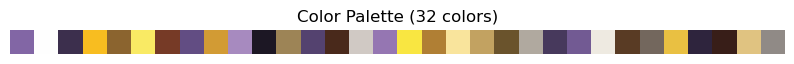

In [3]:
from sklearn.cluster import KMeans

# Extract a color palette from the original image (32 colors)
def extract_color_palette(image, n_colors=32):
    # Reshape the image to be a list of pixels
    pixels = image.reshape(-1, 3)
    
    # Use K-means clustering to find the most common colors
    kmeans = KMeans(n_clusters=n_colors, random_state=42)
    kmeans.fit(pixels)
    
    # Get the colors as RGB values in range [0, 1]
    colors = kmeans.cluster_centers_
    
    # Ensure colors are in valid range [0, 1]
    colors = np.clip(colors, 0, 1)
    
    return colors

# Extract color palette from the original image
COLOR_PALETTE = extract_color_palette(original_image, n_colors=32)

# Display the color palette
plt.figure(figsize=(10, 2))
plt.imshow([COLOR_PALETTE])
plt.axis('off')
plt.title('Color Palette (32 colors)')
plt.show()

## Configure parameters for ellipses

In [ ]:
# RGB mean and std taken from the original image
RGB_MEAN, RGB_STD = np.mean(original_image, axis=(0, 1)), np.std(original_image, axis=(0, 1))

# Image's width and height
IMG_HEIGHT, IMG_WIDTH = original_image.shape[:2]

# New parameters for ellipses
# RGB + (center_X, center_Y, radius_X, radius_Y)
N_PROPERTIES = 3 + 4 + 1

# Number of shapes for each paintings "layers"
# Old Spyro values
# N_SHAPES_LIST = [60, 35, 25, 15, 10, 5]
# Balloon values
N_SHAPES_LIST = [60, 35, 25, 15, 10]

# Number of populations individuals for each paintings "layers"
# Old Spyro values
# N_INDIVIDUAL_LIST = [50, 100, 200, 250, 300, 400]
# Balloon values
N_INDIVIDUAL_LIST = [75, 150, 300, 400, 500]

# The number of painting layers
N_STEP = len(N_SHAPES_LIST)

## Initial population

In [5]:
def generate_random_chromosomes(n_shapes):
    chromosomes = np.empty((n_shapes * N_PROPERTIES))

    for shape_idx in range(0, n_shapes * N_PROPERTIES, N_PROPERTIES):
        # Generate chromosome color values - closest to a palette color
        random_color_idx = np.random.randint(0, len(COLOR_PALETTE))
        chromosomes[shape_idx : (shape_idx + 3)] = COLOR_PALETTE[random_color_idx]
        
        # Generate ellipse parameters
        # Center X, Center Y, Radius X, Radius Y
        chromosomes[(shape_idx + 3) : (shape_idx + 7)] = np.random.uniform(0, 1, size=4)
        
        # Make sure radiuses are not too big and too small
        chromosomes[(shape_idx + 5)] = 0.05 + 0.001 * chromosomes[(shape_idx + 5)]  # radius_x
        chromosomes[(shape_idx + 6)] = 0.05 + 0.001 * chromosomes[(shape_idx + 6)]  # radius_y
    
    return np.clip(chromosomes, 0, 1)

In [6]:
def draw_individual(chromosome, canvas):
    """Draw the individual's ellipses on a canvas"""
    # Make a copy of the canvas so we don't modify the original
    canvas = canvas.copy()
    
    # Reshape the chromosome into shapes
    shapes = np.array(chromosome).reshape((len(chromosome) // N_PROPERTIES, N_PROPERTIES))
    
    # Iterate through each shape and draw it
    for shape in shapes:
        # Extract color components (RGB)
        r, g, b = shape[0], shape[1], shape[2]
        
        # Extract ellipse parameters
        center_x = int(shape[3] * IMG_WIDTH)
        center_y = int(shape[4] * IMG_HEIGHT)
        radius_x = max(1, int(shape[5] * IMG_WIDTH / 2))  
        radius_y = max(1, int(shape[6] * IMG_HEIGHT / 2))
        angle = int(shape[5] * 360)  
        
        color = tuple(shape[:3])

        # Draw the ellipse - using the correct OpenCV format
        # Parameters: image, center, axes, angle, startAngle, endAngle, color, thickness
        try:
            cv2.ellipse(
                img=canvas,
                center=(center_x, center_y),
                axes=(radius_x, radius_y),
                angle=angle,
                startAngle=0,
                endAngle=360,
                color=color,
                thickness=-1  # Filled ellipse
            )
        except Exception as e:
            print(f"Error drawing ellipse: {e}")
            print(f"Center: {(center_x, center_y)}, Axes: {(radius_x, radius_y)}, Color: {bgr_color}")
            # If drawing fails, continue with the next shape
            continue
    
    return canvas

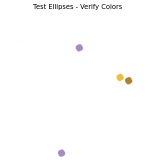

In [7]:
# Test drawing function with a random chromosome
test_chromosome = generate_random_chromosomes(5)  # Create a small test chromosome
test_canvas = np.full_like(original_image, fill_value=1)  # Create a black canvas
test_image = draw_individual(test_chromosome, test_canvas)

# Display the test image to verify colors are working
plt.figure(dpi=40)
plt.imshow(test_image)
plt.title("Test Ellipses - Verify Colors")
plt.axis('off')
plt.show()

## Fitness function

In [8]:
def fitness_function(canvas):
    def fitness_func(ga_instance, solution, solution_idx):
        solution_image = draw_individual(solution, canvas)
        # Basic MSE error
        pixel_error = np.sum((original_image - solution_image) ** 2)
        
        # Calculate weighted combined error
        total_error = pixel_error # + freq_error  

        return -total_error
    return fitness_func

## Callback function

In [9]:
def on_gen(canvas):
    def on_generation(ga_instance):
        # Display the solution fitness and painting each 50 generations
        if (ga_instance.generations_completed - 1) % 50 == 0:
            solution, solution_fitness, solution_idx = ga_instance.best_solution()
            print("Generation: ", ga_instance.generations_completed, ". Fitness: ", solution_fitness)
            
            # Paint the best solution over the canvas
            solution_image = draw_individual(solution, canvas=canvas)
            
            # Plot it
            plt.figure(dpi=40)
            plt.imshow(solution_image, vmin=0, vmax=1)
            plt.axis('off')
            plt.show()
            
            # Add this painting to a solution images list
            solution_images.append(solution_image)
    return on_generation

## GA

Saving results to: results/run_2025-05-21_15-56-35

STEP 1/3: 60 shapes with 75 individuals
Generation:  1 . Fitness:  -20114.748


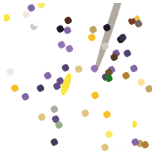

Generation:  51 . Fitness:  -8344.896


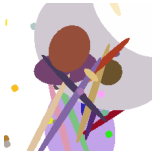

Generation:  101 . Fitness:  -7247.329


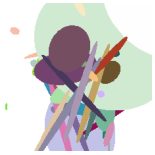

Generation:  151 . Fitness:  -6489.473


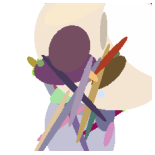

Generation:  201 . Fitness:  -6097.8125


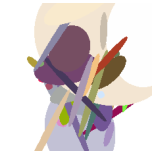

Generation:  251 . Fitness:  -5793.724


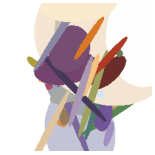

Generation:  301 . Fitness:  -5686.8955


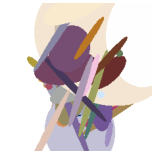

Generation:  351 . Fitness:  -5531.176


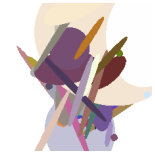

Generation:  401 . Fitness:  -5357.926


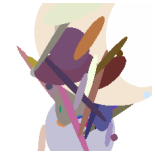

Generation:  451 . Fitness:  -5170.679


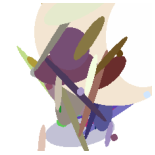

Generation:  501 . Fitness:  -5079.7407


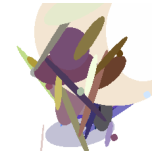

Generation:  551 . Fitness:  -5039.091


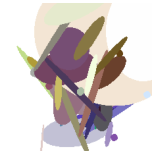

Generation:  601 . Fitness:  -4965.609


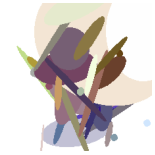

Generation:  651 . Fitness:  -4889.09


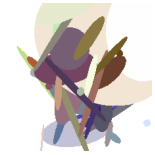

Generation:  701 . Fitness:  -4817.3115


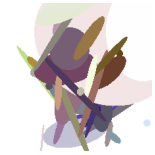

Generation:  751 . Fitness:  -4796.7515


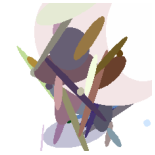

Generation:  801 . Fitness:  -4701.169


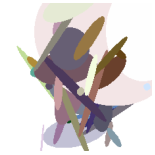

Generation:  851 . Fitness:  -4658.168


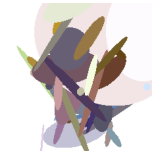

Generation:  901 . Fitness:  -4641.594


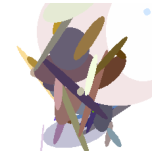

Generation:  951 . Fitness:  -4564.5356


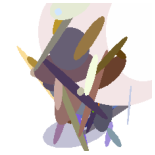

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


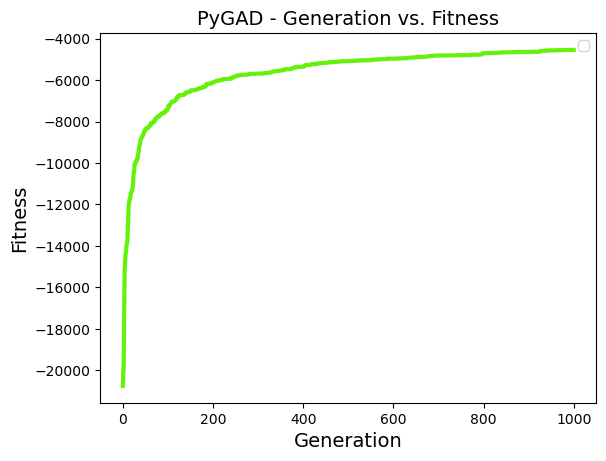

Parameters of the best solution : [0.37799687 0.21555969 0.84071374 0.53934183 0.5051141  0.18378717
 0.41847269 0.36905545 0.23677009 0.81099505 0.42316526 0.88265179
 0.02732459 0.23381567 0.51035048 0.97265949 0.71016534 0.91962552
 0.60095844 0.44463541 0.0065762  0.10493958 0.3567883  0.98412041
 0.41856389 0.64651236 0.03187144 0.69895005 0.74852944 0.08681496
 0.15827066 0.42497841 0.19462828 0.76815279 0.52623675 0.5842031
 0.38435548 0.35801968 0.59695541 0.56982319 0.81230853 0.7599311
 0.83538139 0.4875918  0.86461579 0.46202102 0.20564016 0.54732699
 0.00909805 0.42133148 0.81617551 0.34805393 0.47418388 0.0024366
 0.0508265  0.62864555 0.22782355 0.17727431 0.44842424 0.67137612
 0.75879533 0.43238141 0.05779047 0.12639503 0.11971559 0.89043369
 0.55794283 0.57677076 0.2082761  0.16204791 0.4729995  0.67368111
 0.3130562  0.01929602 0.74882811 0.55519989 0.10368156 0.30477328
 0.05085999 0.92317468 0.4992389  0.45720357 0.72379514 0.88679603
 0.63573955 0.94920353 0.050278

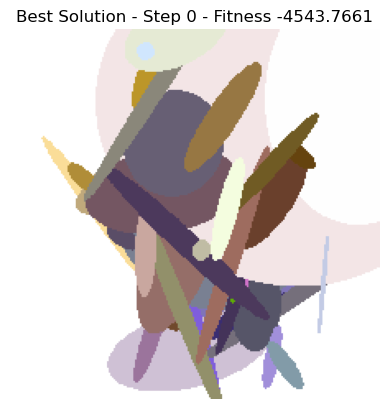


STEP 2/3: 35 shapes with 150 individuals
Generation:  1 . Fitness:  -5852.826


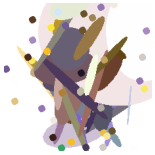

Generation:  51 . Fitness:  -4369.0015


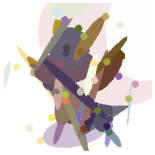

Generation:  101 . Fitness:  -4150.5845


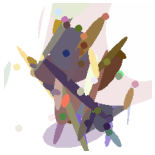

Generation:  151 . Fitness:  -4002.255


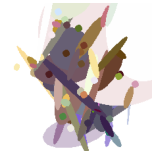

Generation:  201 . Fitness:  -3876.55


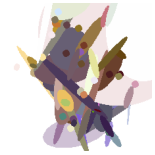

Generation:  251 . Fitness:  -3775.9626


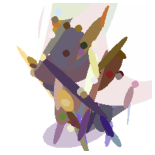

Generation:  301 . Fitness:  -3702.67


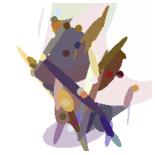

Generation:  351 . Fitness:  -3667.831


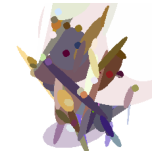

Generation:  401 . Fitness:  -3614.5112


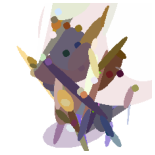

Generation:  451 . Fitness:  -3592.707


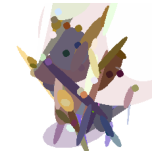

Generation:  501 . Fitness:  -3566.532


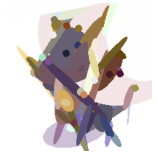

Generation:  551 . Fitness:  -3541.7869


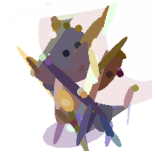

Generation:  601 . Fitness:  -3517.286


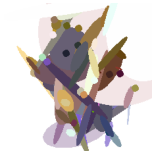

Generation:  651 . Fitness:  -3487.1846


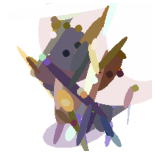

Generation:  701 . Fitness:  -3469.0603


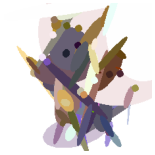

Generation:  751 . Fitness:  -3452.7673


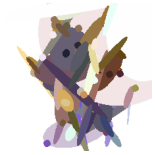

Generation:  801 . Fitness:  -3411.1377


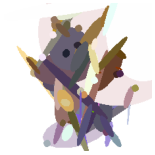

Generation:  851 . Fitness:  -3396.4058


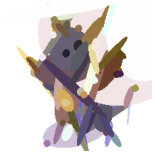

Generation:  901 . Fitness:  -3385.3354


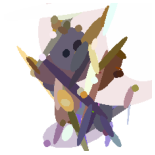

Generation:  951 . Fitness:  -3363.4556


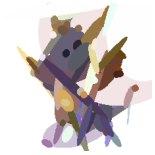

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


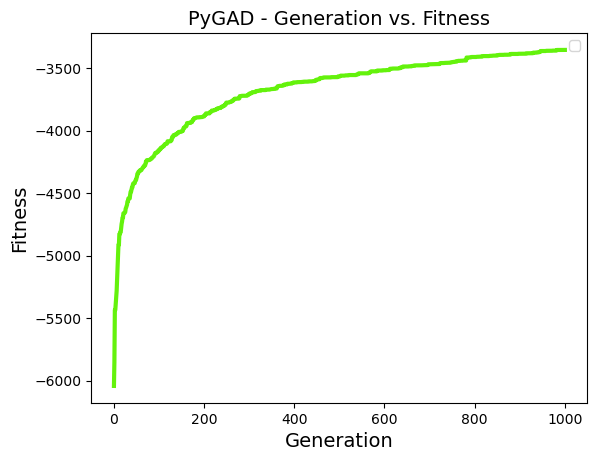

Parameters of the best solution : [0.97857273 0.91962552 0.93366973 0.32955595 0.21385269 0.05069562
 0.05065492 0.62212505 0.91193952 0.98060265 0.93691715 0.42885883
 0.88517488 0.06876491 0.11963629 0.92923985 0.27025791 0.2329036
 0.29993539 0.52366976 0.4368006  0.33595128 0.050801   0.08074813
 0.1214588  0.1299437  0.19549234 0.41833638 0.33950783 0.05054163
 0.05807453 0.85216292 0.34053851 0.3240218  0.48060949 0.54391212
 0.82591031 0.05024471 0.30142197 0.06940747 0.81330527 0.57481295
 0.34064808 0.53962514 0.62020444 0.05087847 0.05067784 0.93959929
 0.60545875 0.46406847 0.31511552 0.35398682 0.14623744 0.06851741
 0.07425662 0.14967049 0.95792827 0.89497787 0.97757031 0.26012683
 0.36773036 0.04349671 0.05071496 0.86150356 0.47143983 0.3576234
 0.64558834 0.51815508 0.68730763 0.07986327 0.04711129 0.32416987
 0.26076676 0.14200142 0.125655   0.76238418 0.48045511 0.05078894
 0.05043608 0.61833572 0.4497075  0.25361835 0.38814542 0.69278069
 0.87548821 0.05070298 0.05094

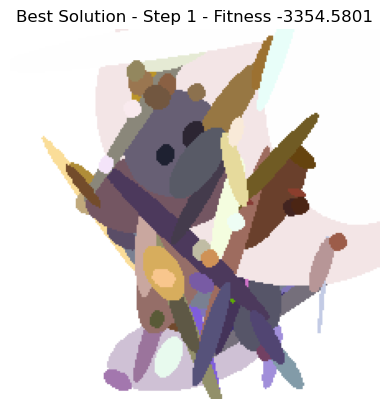


STEP 3/3: 25 shapes with 300 individuals
Generation:  1 . Fitness:  -4200.0376


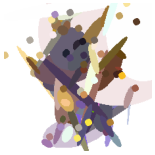

Generation:  51 . Fitness:  -3278.6873


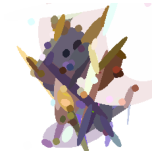

Generation:  101 . Fitness:  -3181.051


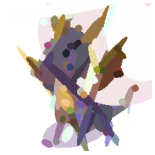

Generation:  151 . Fitness:  -3131.8462


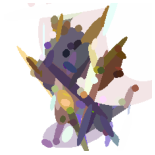

Generation:  201 . Fitness:  -3061.1216


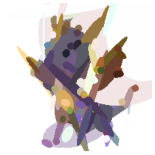

Generation:  251 . Fitness:  -3030.4536


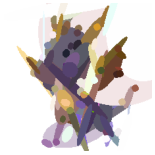

Generation:  301 . Fitness:  -3006.3813


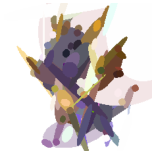

Generation:  351 . Fitness:  -2978.9749


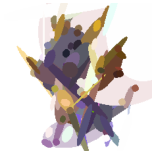

Generation:  401 . Fitness:  -2966.7966


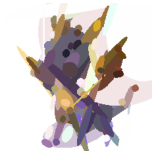

Generation:  451 . Fitness:  -2953.1526


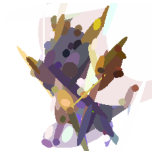

Generation:  501 . Fitness:  -2937.7915


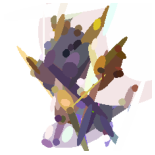

Generation:  551 . Fitness:  -2927.5125


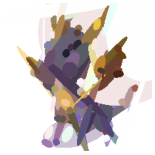

Generation:  601 . Fitness:  -2917.8545


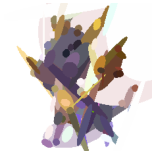

Generation:  651 . Fitness:  -2910.1313


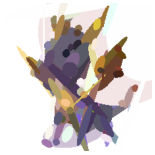

Generation:  701 . Fitness:  -2903.5054


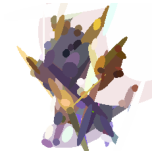

Generation:  751 . Fitness:  -2889.5154


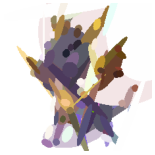

Generation:  801 . Fitness:  -2880.2942


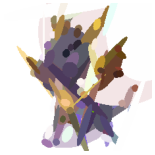

Generation:  851 . Fitness:  -2875.994


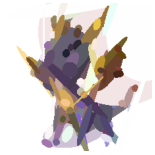

Generation:  901 . Fitness:  -2873.407


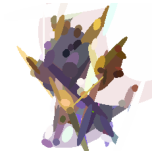

Generation:  951 . Fitness:  -2870.6443


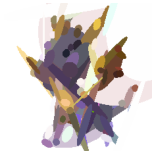

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


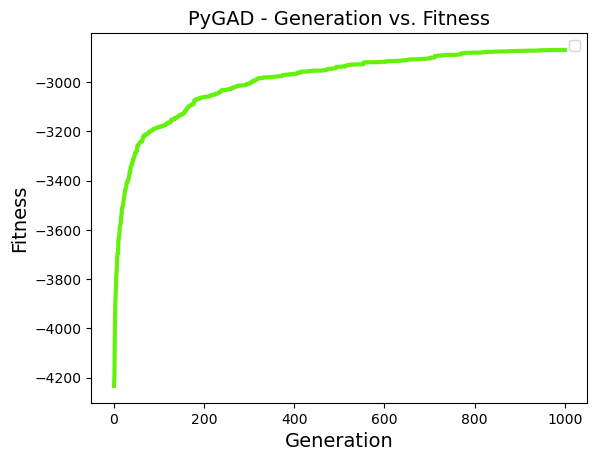

Parameters of the best solution : [4.59481959e-01 4.09500401e-01 5.84087075e-01 3.53394954e-01
 9.40099416e-01 5.07868202e-02 5.15926110e-02 8.90481605e-02
 5.01877095e-01 4.40612698e-01 4.63678068e-01 3.52993157e-01
 7.78098753e-01 2.97544487e-02 1.78888965e-01 7.47358156e-01
 9.12997295e-01 8.93697640e-01 9.43566583e-01 6.88890153e-01
 9.13314957e-01 8.31545333e-02 5.07006742e-02 8.79364816e-01
 9.88281467e-01 9.50271789e-01 9.45008757e-01 5.17735796e-01
 5.30413588e-01 5.04524487e-02 5.03345733e-02 8.73637317e-01
 4.95839871e-01 3.91129458e-01 5.96290570e-01 4.57688400e-01
 4.05699852e-01 7.59784781e-02 1.61763035e-01 3.74056199e-01
 4.52763922e-01 2.07483386e-01 1.24224518e-01 7.72105582e-01
 3.06702100e-01 5.02388936e-02 5.04074827e-02 2.27212702e-01
 7.43241239e-01 5.83282667e-01 1.78230952e-01 6.48854913e-01
 4.18321355e-01 6.06354248e-02 1.40860345e-01 5.61681564e-01
 3.91189600e-01 3.02975703e-01 4.37070817e-01 3.04984148e-01
 3.74553849e-01 6.83115751e-02 1.28570646e-01 4.225

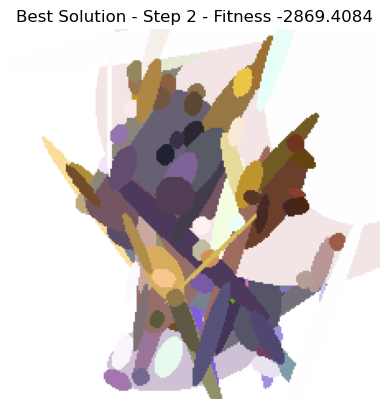


All results saved to: results/run_2025-05-21_15-56-35


In [10]:
import os
import datetime
import json
import pygad
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Function to create a directory with timestamp
def create_timestamp_directory(base_dir="results"):
    """Create a directory with the current date and time for saving results."""
    # Format: 'results/2025-05-15_14-30-45'
    timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    dir_name = os.path.join(base_dir, f"run_{timestamp}")
    
    # Create directory structure
    try:
        if not os.path.exists(base_dir):
            os.makedirs(base_dir)
        if not os.path.exists(dir_name):
            os.makedirs(dir_name)
        # Create subdirectories for organization
        os.makedirs(os.path.join(dir_name, "images"), exist_ok=True)
        os.makedirs(os.path.join(dir_name, "plots"), exist_ok=True)
        os.makedirs(os.path.join(dir_name, "data"), exist_ok=True)
    except OSError as e:
        print(f"Error creating directories: {e}")
        # Fallback to simple directory in current working directory
        dir_name = f"results_{timestamp}"
        os.makedirs(dir_name, exist_ok=True)
    
    return dir_name

# Create the directory at the beginning
results_dir = create_timestamp_directory()
print(f"Saving results to: {results_dir}")

MUTATION_PROBABILITY = [0.05, 0.01]
CROSSOVER_PROBABILITY = 0.9
PARENT_SELECTION_TYPE = "tournament"
K_TOURNAMENT = 5

# Save experiment configuration
try:
    experiment_config = {
        "N_STEP": N_STEP,
        "N_SHAPES_LIST": N_SHAPES_LIST,
        "N_INDIVIDUAL_LIST": N_INDIVIDUAL_LIST,
        "N_PROPERTIES": N_PROPERTIES,
        "MUTATION_PROBABILITY": MUTATION_PROBABILITY,
        "CROSSOVER_PROBABILITY": CROSSOVER_PROBABILITY,
        "PARENT_SELECTION_TYPE": PARENT_SELECTION_TYPE,
        "K_TOURNAMENT": K_TOURNAMENT,
        "timestamp": datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    with open(os.path.join(results_dir, "experiment_config.json"), 'w') as f:
        json.dump(experiment_config, f, indent=4)
except Exception as e:
    print(f"Warning: Failed to save experiment configuration: {e}")

solution_images = []
solution_fitnesses = []

# Loop over painting layers
for step in range(N_STEP):
    n_shapes = N_SHAPES_LIST[step]
    n_individual = N_INDIVIDUAL_LIST[step]
    
    print(f"\n{'='*50}")
    print(f"STEP {step+1}/{N_STEP}: {n_shapes} shapes with {n_individual} individuals")
    print(f"{'='*50}")
    
    # Generate an initial population
    initial_population = [generate_random_chromosomes(n_shapes) for i in np.arange(n_individual)]
    
    # Use a black canvas if this is the first painting layer
    # otherwise use the previous best image as canvas
    if step == 0:
        canvas = np.full_like(original_image, fill_value=1)
    else:
        canvas = best_solution_image.copy()
    
    # Define min and max values for each genes
    gene_space = [{'low': 0, 'high': 1}] * N_PROPERTIES * n_shapes
    
    # Create a new genetic algorithm instance
    ga_instance = pygad.GA(
        num_generations=1000, 
        num_parents_mating=round(0.2 * len(initial_population)),
        fitness_func=fitness_function(canvas),
        initial_population=initial_population,
        gene_type=float,
        gene_space=gene_space,
        on_generation=on_gen(canvas),
        random_mutation_min_val=-0.15,
        random_mutation_max_val=0.15,
        mutation_type="adaptive",
        mutation_probability=MUTATION_PROBABILITY,
        crossover_type="two_points",
        crossover_probability=CROSSOVER_PROBABILITY,
        parent_selection_type=PARENT_SELECTION_TYPE,
        K_tournament=K_TOURNAMENT,
        keep_elitism=5,
        stop_criteria="saturate_50",
        # save_solutions=True,
    )
    
    # Run genetic algorithm
    ga_instance.run()
    
    # Save fitness plot
    try:
        fig_fitness = ga_instance.plot_fitness()
        fitness_plot_path = os.path.join(results_dir, "plots", f"fitness_plot_step_{step}.png")
        fig_fitness.savefig(fitness_plot_path)
        plt.close(fig_fitness)
    except Exception as e:
        print(f"Warning: Could not save fitness plot: {e}")
    
    
    # Print best solution results
    solution, solution_fitness, solution_idx = ga_instance.best_solution()
    print("Parameters of the best solution : {solution}".format(solution=solution))
    print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))
    print("Index of the best solution : {solution_idx}".format(solution_idx=solution_idx))
    
    # Save solution parameters
    try:
        solution_data = {
            "fitness": float(solution_fitness),
            "solution_idx": int(solution_idx),
            "solution_params": solution.tolist() if hasattr(solution, 'tolist') else solution
        }
        with open(os.path.join(results_dir, "data", f"solution_data_step_{step}.json"), 'w') as f:
            json.dump(solution_data, f, indent=4)
    except Exception as e:
        print(f"Warning: Failed to save solution data: {e}")
    
    # Get best solution image
    best_solution_image = draw_individual(solution, canvas=canvas)
    solution_images.append(best_solution_image)
    solution_fitnesses.append(float(solution_fitness))
    
    # Save the best solution image
    plt.figure(dpi=100)
    plt.imshow(best_solution_image, vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f'Best Solution - Step {step} - Fitness {solution_fitness:.4f}')
    best_image_path = os.path.join(results_dir, "images", f"best_solution_step_{step}.png")
    plt.savefig(best_image_path, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close()
    
    # Save the raw numpy array for potential later use
    np_image_path = os.path.join(results_dir, "data", f"best_solution_step_{step}.npy")
    np.save(np_image_path, best_solution_image)

# Save a summary of the fitness progression
plt.figure(figsize=(10, 6))
plt.plot(range(len(solution_fitnesses)), solution_fitnesses, 'o-', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Fitness')
plt.title('Fitness Progression Across Steps')
plt.grid(True)
fitness_summary_path = os.path.join(results_dir, "plots", "fitness_progression.png")
plt.savefig(fitness_summary_path)
plt.close()

#
# Save the final solution separately
plt.figure(figsize=(10, 10), dpi=150)
plt.imshow(solution_images[-1], vmin=0, vmax=1)
plt.axis('off')
plt.title(f'Final Solution - Fitness: {solution_fitnesses[-1]:.4f}')
final_image_path = os.path.join(results_dir, "final_solution.png")
plt.savefig(final_image_path, bbox_inches='tight', pad_inches=0.1)
plt.close()

# Create a README file with experiment information
readme_content = f"""# Genetic Algorithm Painting Results

Experiment run on: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Directory Structure
- `images/`: Contains the best solution images for each step
- `plots/`: Contains fitness and diversity plots
- `data/`: Contains raw data (numpy arrays and JSON files)

## Experiment Configuration
- Number of steps: {N_STEP}
- Number of shapes per step: {N_SHAPES_LIST}
- Population size per step: {N_INDIVIDUAL_LIST}

## Files
- `final_solution.png`: The final painting result
- `evolution_animation.mp4`: Animation showing the evolution of the painting
- `experiment_config.json`: Detailed configuration of the experiment
- `fitness_progression.png`: Plot showing fitness improvement across steps
"""

with open(os.path.join(results_dir, "README.md"), 'w') as f:
    f.write(readme_content)

print(f"\nAll results saved to: {results_dir}")
print(f"{'='*50}")